# Ten-year multi-image light curves and survey observations

The intrinsic driver belongs to the shared source. This example uses `ModulatedSource` explicitly for multiplicative brightness modulation. A `KerrDiskModel` can instead own the driver and calculate its delayed thermal response. Pass only the source to `MultiImageSystem`. Sources without drivers also work, and explicit `apply_driving_signal=True` requires an attached driver.


Each macroimage has an independent moving star field, local macro model, and
arrival delay, while all images share one stochastic intrinsic driver. Maps
are generated every 25 days and the source is evaluated daily for ten years.
At each daily epoch the code interpolates the two bracketing map--source
contractions, retaining at most two maps instead of constructing daily maps.
Physical Jy fluxes use the AB zero point, so both truth curves and noisy observations
are shown in magnitudes.

If `MICROCAUSTICS_LSST_OPSIM` points to a Rubin OpSim SQLite database, the
notebook builds a reusable `RubinOpSimCadenceIndex` and selects a reproducible
random WFD field with `rubin.sample`. Otherwise it uses a deterministic sparse
fallback cadence with the same public observation interface. This keeps the
large survey database optional rather than bundling it in the package.


In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())

import os
from pathlib import Path
import numpy as np


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
lens_redshift, source_redshift = 0.5, 1.5
source_resolution = 1024 if use_cuda else 256
base_model = mc.GaussianModel(
    sigma_uas=(0.08, 0.12),
    bands_angstrom={"g": 4800.0, "i": 7500.0},
    source_grid_shape=source_resolution,
    enclosed_flux_fraction=0.999,
    source_margin=1.05,
)
driver_times = torch.arange(-50.0, 3651.0)
driver = mc.broken_power_law_driving_signal(
    driver_times,
    break_timescale_days=200.0,
    alpha_L=1.0,
    alpha_R=3.0,
    standard_deviation=0.10,
    seed=0,
    extrapolation="hold",
)
source = mc.ModulatedSource(base_model, driver)

population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.SkyProjectedKinematics(
        ra_deg=150.0, dec_deg=20.0,
        stellar_dispersion_km_s=170.0,
        peculiar_velocity_dispersion_km_s=235.0,
        include_cmb_dipole=True, seed=0,
    ),
)
method = mc.production_ipm_config(
    rays=10_000_000 if use_cuda else 262_144,
)

# One shared physical prescription is expanded into independent seeded star
# fields for the two macroimages. Scalars can be replaced by per-image
# mappings whenever the observed images require different assumptions.
system = mc.MultiImageSystem(
    lens_redshift=lens_redshift,
    source_redshift=source_redshift,
    images={
        "A": mc.MacroLens(convergence=0.25, shear=0.12),
        "B": mc.MacroLens(convergence=0.25, shear=0.18),
    },
    source=source,
    stellar_population=population,
    integration_domain="scout",
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed={"A": 0, "B": 1},
    arrival_time_delays_days={"A": 0.0, "B": 8.0},
    methods=method,
    runtime=runtime_config,
    caustic_grid_shape=256,
)


src\microcaustics\solvers\ipm.py:900: CompilationWarning: Compilation event 1: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


src\microcaustics\solvers\ipm.py:1289: CompilationWarning: Compilation event 2: preparing a new Triton specialization for batched IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


(<Figure size 700x430 with 2 Axes>,
 array([<Axes: title={'center': 'Image A  ($\\Delta t=0$ d)'}, xlabel='Time [days]', ylabel='Brightness [AB mag]'>,
        <Axes: title={'center': 'Image B  ($\\Delta t=8$ d)'}, xlabel='Time [days]', ylabel='Brightness [AB mag]'>],
       dtype=object))

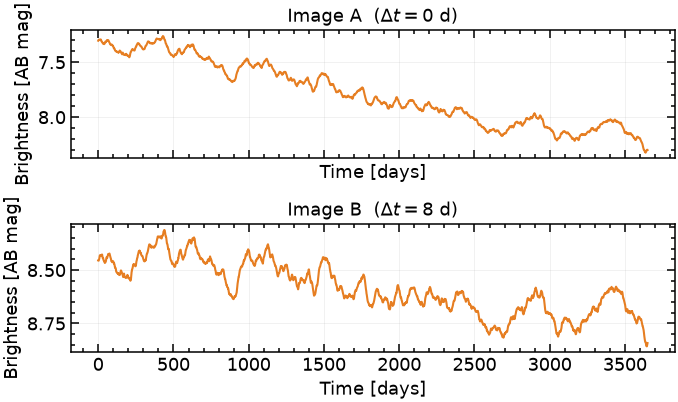

In [3]:
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
curves = system.light_curves(
    duration_days=3650, map_cadence_days=25, source_cadence_days=1,
    temporal_batch_size=49, scout_refresh_frames=10,
)
mcp.plot_multi_image_light_curves(
    curves,
    band="i",
    magnitude=True,
    normalize=False,
)


Using Rubin OpSim WFD cadence: baseline_v4.3.5_10yrs.db {'survey': 'Rubin WFD', 'selection': 'random_wfd', 'field_ra_deg': 236.1927490234375, 'field_dec_deg': -52.34151840209961, 'selection_radius_deg': 1.75, 'source_visit_index': 1722238, 'seed': 0, 'database': 'baseline_v4.3.5_10yrs.db', 'survey_start_mjd': 60980.00158187724, 'selected_bands': ('g', 'i'), 'parent_visit_count': 712}


(<Figure size 640x380 with 1 Axes>,
 <Axes: title={'center': 'Observed image A'}, xlabel='Time [days]', ylabel='Brightness [mag]'>)

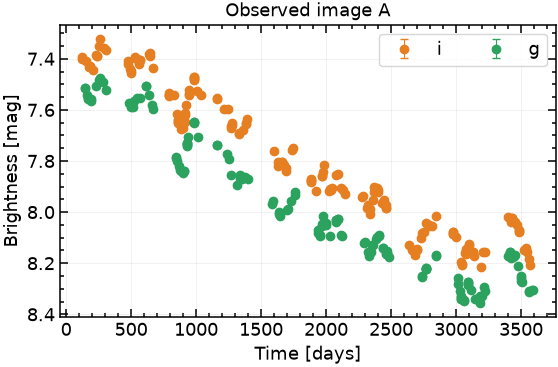

In [4]:
opsim_path = mc.find_rubin_opsim_database()
if opsim_path is not None:
    rubin = mc.RubinOpSimCadenceIndex.from_database(opsim_path)
    cadence = rubin.sample(
        seed=0,
        survey="wfd",
        duration_days=3650.0,
    )
    cadence = cadence.select_bands(base_model.band_names)
    print("Using Rubin OpSim WFD cadence:", opsim_path.name, cadence.metadata)
else:
    visit_times = np.arange(2.0, 3650.0, 5.0)
    visit_bands = tuple(("g", "i")[index % 2] for index in range(len(visit_times)))
    cadence = mc.SurveyCadence(
        visit_times,
        visit_bands,
        np.full(len(visit_times), 25.0),
        metadata={"survey": "deterministic tutorial fallback"},
    )
    print("No OpSim database found; using the deterministic fallback cadence.")
observations = mc.observe_multi_image_light_curves(
    curves,
    cadence,
    seed=0,
)
mcp.plot_photometric_observations(
    observations,
    image="A",
    marker_size=6.0,
    capsize=3.0,
)